In [1]:
# Step 1: Import the required modules
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [4]:
data=pd.read_csv("user_personalized_features.csv")

In [5]:
# Remove unnecessary columns
data.drop(['Unnamed: 0', ], axis=1, inplace=True)
data.head(10)#sample of 10

,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True
5,#6,38,Male,Suburban,25926,Travel,22,8,25,2669,Books,520,28,False
6,#7,56,Male,Urban,124555,Fashion,11,7,152,1113,Home & Kitchen,330,31,True
7,#8,36,Male,Urban,29496,Technology,26,7,108,2151,Apparel,558,19,True
8,#9,40,Male,Rural,76447,Travel,25,6,130,4085,Books,325,3,True
9,#10,28,Male,Urban,121604,Food,13,8,61,4999,Electronics,114,36,False


In [24]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# List of numeric columns to convert and clean
numeric_cols = [
    'Age', 'Income', 'Last_Login_Days_Ago', 'Purchase_Frequency', 
    'Average_Order_Value', 'Total_Spending', 'Time_Spent_on_Site_Minutes', 'Pages_Viewed'
]

# Convert numeric columns to numbers; invalid parsing will become NaN
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Replace all NaN values with 0 to avoid issues later
data.fillna(0, inplace=True)

# List of categorical columns to encode
categorical_cols = ['Gender', 'Location', 'Interests', 'Newsletter_Subscription']

# Encode categorical columns using LabelEncoder
for col in categorical_cols:
    if col in data.columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))  # Convert to string before encoding


In [25]:
df.head()

,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


In [26]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Fix random seed for consistent results every run
np.random.seed(42)

# Add 'visitor' column with random values: 'New' or 'Returning'
data['visitor'] = np.random.choice(['New', 'Returning'], size=len(data))

# Add 'bought_count' column with random integers between 0 and 19 (inclusive)
data['bought_count'] = np.random.randint(0, 20, size=len(data))

# Create binary 'purchased' column: 1 if bought_count > 5, else 0
data['purchased'] = (data['bought_count'] > 5).astype(int)

# Convert 'visitor' categories to numbers: New->0, Returning->1
le = LabelEncoder()
data['visitor'] = le.fit_transform(data['visitor'])


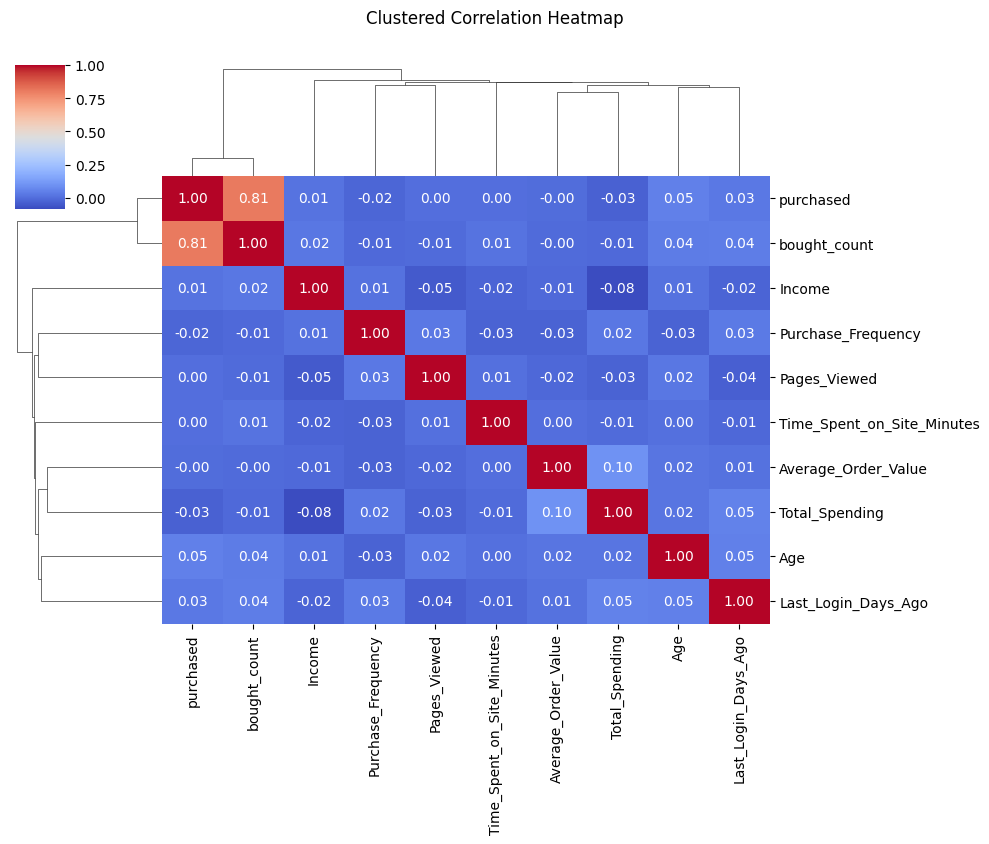

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = numeric_columns + ['purchased', 'bought_count']
corr = data[cols].corr()

# Clustered heatmap groups similar features together for better patterns
sns.clustermap(corr, annot=True, cmap='coolwarm', fmt='.2f', figsize=(10, 8))
plt.suptitle('Clustered Correlation Heatmap', y=1.05)
plt.show()


In [35]:
from sklearn.preprocessing import StandardScaler

# Select feature columns to use for prediction
features = [
    'Age', 'Income', 'Total_Spending', 'Pages_Viewed', 'Gender', 'Location',
    'Interests', 'Newsletter_Subscription', 'Time_Spent_on_Site_Minutes',
    'Purchase_Frequency', 'Average_Order_Value', 'visitor', 'bought_count'
]

# Prepare input features (X) and target variable (y)
X = data[features]
y = data['purchased']  # Target: whether user purchased or not

# Scale features to have mean=0 and std=1 (important for many ML models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [36]:
# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

False Positives: 0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       108
           1       1.00      1.00      1.00       137

    accuracy                           1.00       245
   macro avg       1.00      1.00      1.00       245
weighted avg       1.00      1.00      1.00       245

Model Accuracy: 1.0


C:\Users\User\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:30:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


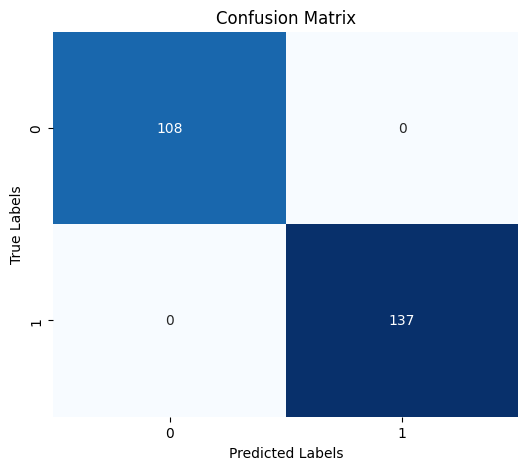

In [37]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

y_pred_prob = xgb.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred_class = (y_pred_prob >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_class).ravel()
print(f"False Positives: {fp}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_class))
print("Model Accuracy:", accuracy_score(y_test, y_pred_class))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
